# S12 – Последовательности и время: temporal split, лаговые признаки и baseline-модели

В этом ноутбуке разберём базовую, но очень важную практику работы с временными рядами:

- почему для времени нужен **temporal split**, а не обычный `random split`,
- как строить **лаговые признаки** и **rolling-признаки**,
- зачем обязательно считать **baseline-модели** до любых LSTM/GRU,
- как распознать **leakage** из будущего.

Для демонстрации используем синтетический, но реалистичный ряд «ежедневного спроса», в котором есть:
- тренд,
- недельная и годовая сезонность,
- шум,
- редкие всплески,
- небольшое изменение режима в конце ряда.


## 0. План

К концу ноутбука надо уметь:

1. Объяснить, почему `random split` для временных рядов обычно некорректен.
2. Сделать корректное разбиение `train / validation / test` по времени.
3. Построить лаговые признаки, rolling mean/std и календарные признаки.
4. Посчитать простые baseline-подходы:
   - `naive forecast`,
   - `moving average`,
   - линейную модель (Ridge) на признаках из прошлого,
   - дерево / ансамбль (RandomForest) на тех же признаках.
5. Сравнить модели по `MAE`, `RMSE`, `MAPE`.
6. Понять, какие признаки и операции приводят к утечке информации из будущего.


## 1. Импорты и общие настройки

In [1]:
# Базовые библиотеки для генерации данных, анализа и обучения простых моделей.
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
# Фиксируем seed, чтобы синтетический ряд и результаты были воспроизводимыми.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)


## 2. Данные и первичный анализ

Ниже генерируем один временной ряд `sales` с дневной частотой. Это не «идеальная синусоида», а более жизненный пример:

- есть слабый долгосрочный рост,
- есть недельная сезонность (разные дни недели ведут себя по-разному),
- есть медленная годовая сезонность,
- есть случайный шум,
- есть промо-всплески,
- ближе к концу ряда появляется небольшой сдвиг режима.

Такой пример удобен тем, что на нём хорошо видно, почему работа со временем требует отдельной дисциплины.

In [3]:
def make_synthetic_demand(n_days: int = 1200, start: str = "2021-01-01") -> pd.DataFrame:
    # Строим ежедневную временную шкалу и индекс времени t.
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)

    # Собираем ряд из нескольких компонент: тренд, сезонность, шум и редкие всплески.
    trend = 80 + 0.035 * t
    weekly = 8 * np.sin(2 * np.pi * t / 7) + 3 * np.cos(2 * np.pi * t / 7)
    yearly = 10 * np.sin(2 * np.pi * t / 365.25)
    noise = np.random.normal(loc=0.0, scale=3.2, size=n_days)

    day_of_week = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(day_of_week >= 5, 6.5, 0.0)

    promo = (np.random.rand(n_days) < 0.04).astype(float)
    promo_effect = promo * np.random.uniform(8, 18, size=n_days)

    # В конце ряда добавляем небольшой сдвиг режима, чтобы задача была ближе к жизни.
    regime_shift = np.where(t >= int(n_days * 0.82), 20.0, 0.0)

    sales = trend + weekly + yearly + weekend_bonus + promo_effect + regime_shift + noise
    sales = np.maximum(sales, 5.0)

    df = pd.DataFrame({
        "date": dates,
        "sales": sales,
        "promo": promo.astype(int),
    })
    return df

# Генерируем один демонстрационный ряд, на котором дальше строим все эксперименты.
df = make_synthetic_demand()
df.head()


,date,sales,promo
0,2021-01-01,84.589485,0
1,2021-01-02,94.389691,0
2,2021-01-03,96.118444,0
3,2021-01-04,86.262703,0
4,2021-01-05,73.904287,0


,count,mean,min,25%,50%,75%,max,std
date,1200,2022-08-23 12:00:00,2021-01-01 00:00:00,2021-10-27 18:00:00,2022-08-23 12:00:00,2023-06-19 06:00:00,2024-04-14 00:00:00,NaN
sales,1200.0,107.722038,65.367584,91.741003,104.318509,120.120321,181.191649,21.499368
promo,1200.0,0.04,0.0,0.0,0.0,0.0,1.0,0.196041


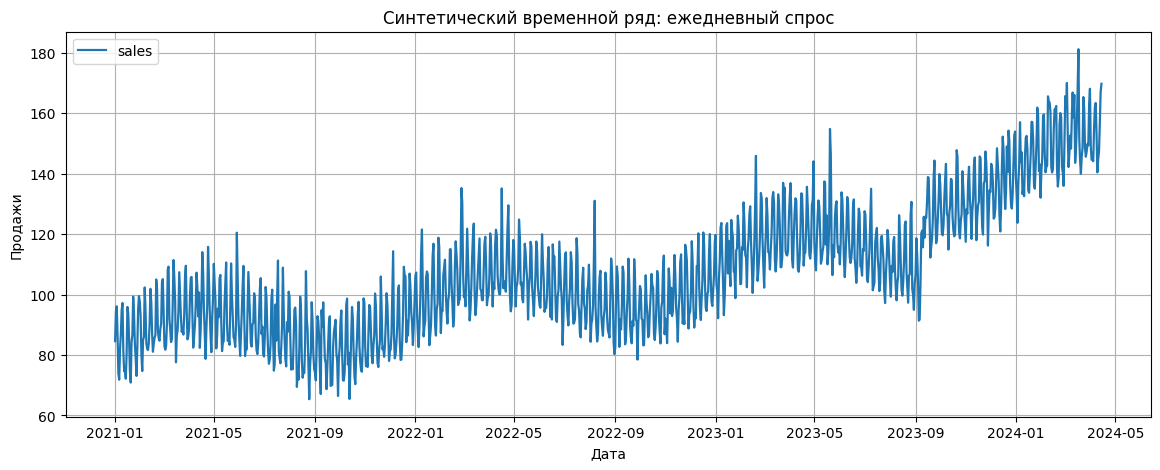

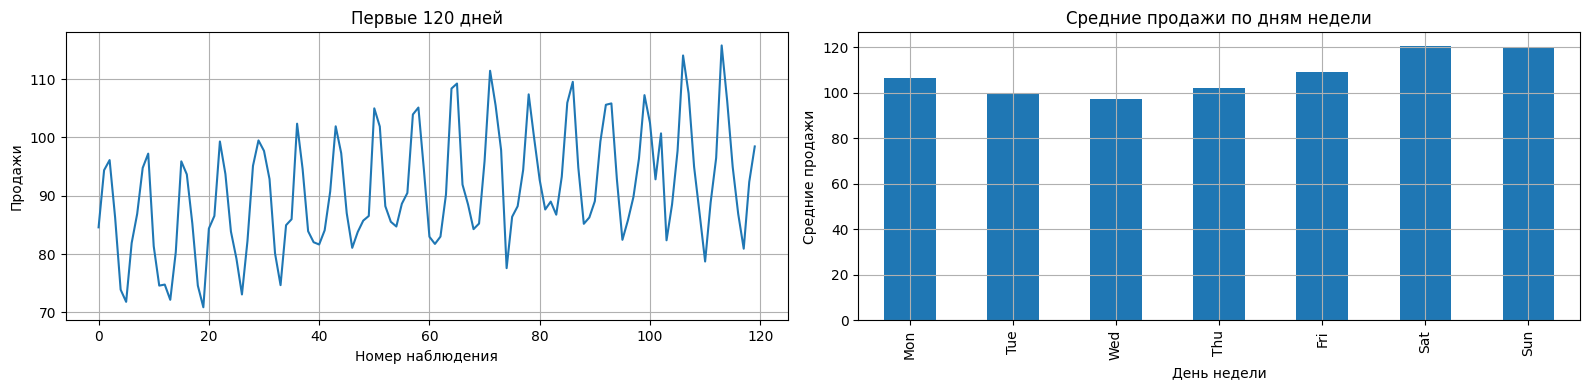

In [4]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["sales"], lw=1.6, label="sales")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["sales"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Продажи")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["sales"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средние продажи")

plt.tight_layout()
plt.show()


## 3. Почему `random split` здесь некорректен

Для обычной табличной выборки случайное перемешивание часто допустимо. Но для временного ряда задача почти всегда звучит так:

> «Используя прошлое, предсказать будущее».

Если мы перемешаем наблюдения случайно, модель будет учиться на поздних датах и тестироваться на ранних. Для прогноза это нереалистично.

Поэтому обычно делаем так:

- `train` – более ранняя часть ряда,
- `validation` – следующий по времени отрезок,
- `test` – самый поздний участок.

Именно такой сценарий ближе к реальному внедрению.

train: 2021-01-01 → 2023-04-20 | 840 строк
val:   2023-04-21 → 2023-10-17 | 180 строк
test:  2023-10-18 → 2024-04-14 | 180 строк


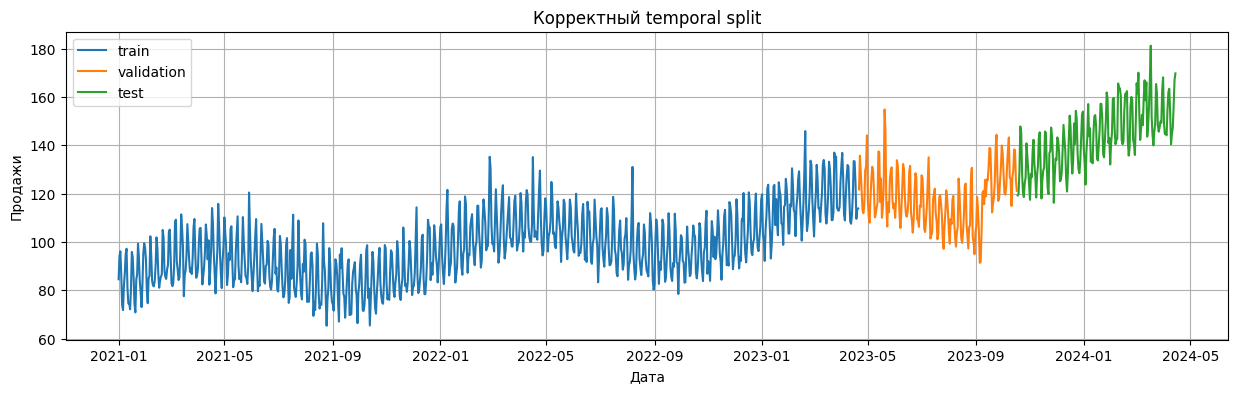

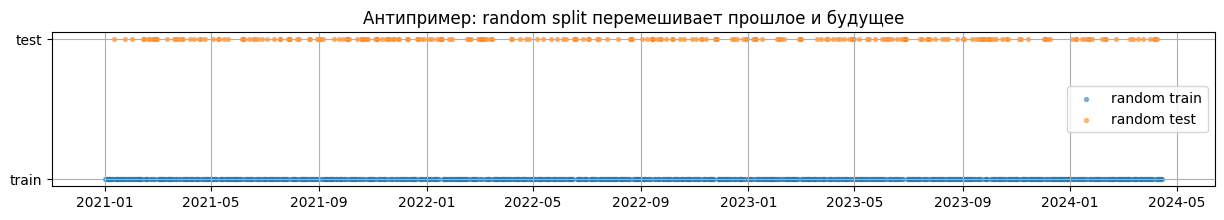

In [5]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["sales"], label="train")
ax.plot(val_df["date"], val_df["sales"], label="validation")
ax.plot(test_df["date"], test_df["sales"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

# Для контраста строим антипример: случайное разбиение перемешивает прошлое и будущее.
random_train_idx, random_test_idx = train_test_split(df.index, test_size=0.2, random_state=42, shuffle=True)

fig, ax = plt.subplots(figsize=(15, 2))
ax.scatter(df.loc[random_train_idx, "date"], np.zeros(len(random_train_idx)), s=8, alpha=0.5, label="random train")
ax.scatter(df.loc[random_test_idx, "date"], np.ones(len(random_test_idx)), s=8, alpha=0.5, label="random test")
ax.set_title("Антипример: random split перемешивает прошлое и будущее")
ax.set_yticks([0, 1])
ax.set_yticklabels(["train", "test"])
ax.legend()
plt.show()


## 4. Признаки для baseline-моделей

Простые регрессионные модели не «понимают время» сами по себе. Поэтому мы явно создаём признаки из прошлого:

- лаги `lag_1`, `lag_7`, `lag_14`, `lag_28`,
- скользящие статистики `rolling_mean`, `rolling_std`,
- календарные признаки: день недели, месяц,
- синус/косинус кодирование дня недели и месяца,
- при необходимости – внешние бинарные признаки, например `promo`.

Ключевая идея: все признаки должны быть вычислены **только из прошлого**.

In [6]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "sales") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()


,date,sales,promo,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,2021-01-29,95.129535,1,4,1,-0.433884,-0.900969,0.500000,0.866025,82.242501,73.084828,79.225235,86.546963,80.355389,84.589485,85.430829,8.814591,84.065902,8.872967
1,2021-01-30,99.491039,0,5,1,-0.974928,-0.222521,0.500000,0.866025,95.129535,82.242501,73.084828,99.306048,95.902625,94.389691,86.656911,9.561017,84.442332,9.116245
2,2021-01-31,97.691081,0,6,1,-0.781831,0.623490,0.500000,0.866025,99.491039,95.129535,82.242501,93.731800,93.668568,96.118444,86.683338,9.601975,84.624523,9.369857
3,2021-02-01,92.864018,0,0,2,0.000000,1.000000,0.866025,0.500000,97.691081,99.491039,95.129535,83.878428,85.251661,86.262703,87.248950,10.185265,84.680689,9.445713
4,2021-02-02,80.133775,0,1,2,0.781831,0.623490,0.866025,0.500000,92.864018,97.691081,99.491039,79.225235,74.597539,73.904287,88.532605,10.255665,84.916450,9.568250


In [7]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "promo",
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "sales"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)


Размерности:
X_train: (820, 17) | y_train: (820,)
X_val:   (176, 17) | y_val:   (176,)
X_test:  (176, 17) | y_test:  (176,)


## 5. Baseline 1: `naive forecast` и `moving average`

Прежде чем обучать более сложные модели, нужно посчитать очень простые ориентиры.

### Naive forecast
Самый базовый вариант: прогноз на следующий шаг равен последнему наблюдённому значению.

### Moving average
Чуть более устойчивый вариант: прогноз берётся как среднее нескольких последних наблюдений.

Такие baseline-модели часто оказываются неожиданно сильными, особенно если ряд гладкий и инерционный.

In [8]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

print("Test:")
display(baseline_results_test)


Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),7.669334,9.761476,6.495348
1,MovingAverage(7),8.354852,10.007560,7.058762


Test:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),7.742091,9.529517,5.418472
1,MovingAverage(7),8.235508,9.586691,5.704636


## 6. Baseline 2: линейная модель и ансамбль деревьев на лаговых признаках

Теперь используем уже не «ручной прогноз», а обычные supervised-модели на признаках из прошлого.

Сделаем две модели:

1. `Ridge` – линейная модель с L2-регуляризацией.
2. `RandomForestRegressor` – ансамбль деревьев, умеющий ловить нелинейные зависимости.

Это хороший ориентир перед переходом к рекуррентным сетям: если простые признаки уже дают достойный результат, нейросеть не всегда нужна.

In [9]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Деревья к масштабу почти нечувствительны, поэтому RandomForest оставляем на исходных признаках.
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_pred_rf = rf.predict(X_val)
test_pred_rf = rf.predict(X_test)

# Сравниваем модели на validation и test в единой таблице метрик.
val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
    evaluate_regression(y_val, val_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "Ridge"),
    evaluate_regression(y_test, test_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

print("Test:")
display(test_results)


Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,4.171599,6.263759,3.449334
1,RandomForest,5.198889,7.275137,4.303628
2,Naive (lag_1),7.669334,9.761476,6.495348
3,MovingAverage(7),8.354852,10.007560,7.058762


Test:


,model,MAE,RMSE,MAPE_%
0,Ridge,2.884621,3.685829,2.017301
1,Naive (lag_1),7.742091,9.529517,5.418472
2,MovingAverage(7),8.235508,9.586691,5.704636
3,RandomForest,14.485369,18.009533,9.543148


### Проверка на test

Лучшая модель на test по MAE: Ridge


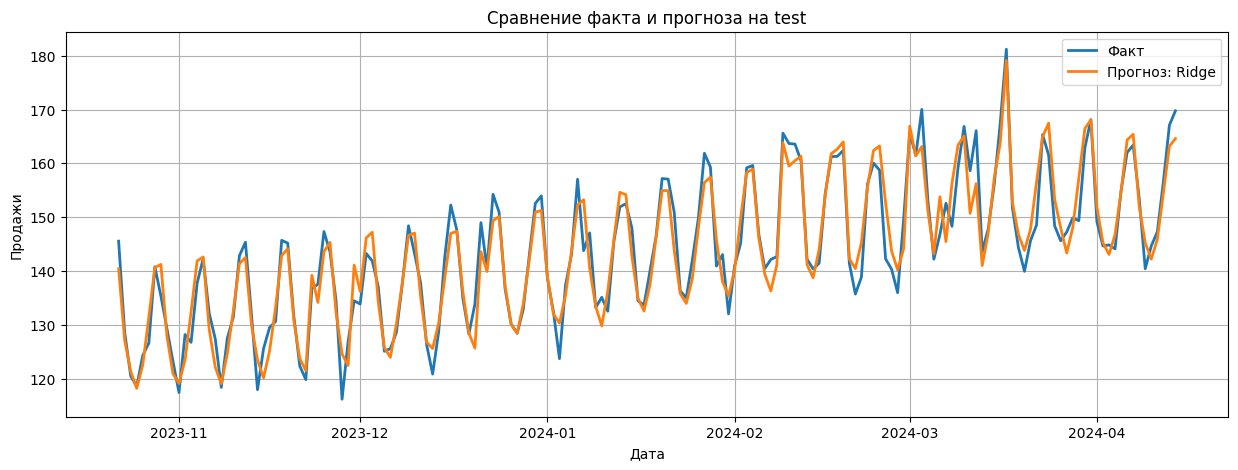

,date,actual,prediction,abs_error
0,2023-10-22,145.560912,140.431926,5.128986
1,2023-10-23,128.658509,127.165305,1.493205
2,2023-10-24,120.537718,121.401531,0.863813
3,2023-10-25,118.605929,118.234855,0.371074
4,2023-10-26,124.369360,122.616601,1.752759
5,2023-10-27,126.621539,131.431706,4.810168
6,2023-10-28,140.802880,140.646100,0.156780
7,2023-10-29,135.403321,141.246323,5.843002
8,2023-10-30,129.268829,127.937613,1.331215
9,2023-10-31,123.235056,120.966679,2.268378


,date,actual,prediction,abs_error
127,2024-02-26,142.298993,152.705176,10.406183
142,2024-03-12,166.073917,156.217592,9.856326
77,2024-01-07,143.800743,153.254336,9.453592
37,2023-11-28,116.217564,124.628284,8.410720
59,2023-12-20,133.907841,125.699822,8.208020
138,2024-03-08,148.308285,156.306557,7.998272
152,2024-03-22,148.562010,156.525766,7.963756
159,2024-03-29,149.354989,157.283939,7.928951
141,2024-03-11,158.638765,150.721240,7.917525
137,2024-03-07,152.593521,145.471210,7.122310


In [10]:
# Берём победителя по MAE на test и визуально проверяем, где именно он ошибается.
best_model_name = test_results.iloc[0]["model"]
pred_map = {
    "Naive (lag_1)": test_pred_naive,
    "MovingAverage(7)": test_pred_ma7,
    "Ridge": test_pred_ridge,
    "RandomForest": test_pred_rf,
}
best_test_pred = pred_map[best_model_name]

print(f"Лучшая модель на test по MAE: {best_model_name}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_feat["date"], y_test.to_numpy(), label="Факт", lw=2)
ax.plot(test_feat["date"], best_test_pred, label=f"Прогноз: {best_model_name}", lw=2)
ax.set_title("Сравнение факта и прогноза на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

comparison_df = pd.DataFrame({
    "date": test_feat["date"].values,
    "actual": y_test.to_numpy(),
    "prediction": best_test_pred,
})
comparison_df["abs_error"] = np.abs(comparison_df["actual"] - comparison_df["prediction"])

# Смотрим и первые наблюдения, и самые крупные промахи модели.
display(comparison_df.head(10))
display(comparison_df.sort_values("abs_error", ascending=False).head(10))


## 7. Leakage: типичные ошибки при работе со временем

На временных данных можно очень легко «нарисовать» себе красивое качество, если случайно использовать будущее.

Ниже покажем три плохих сценария:

1. `random split` для прогноза.
2. Признак со скользящим средним, рассчитанным с `center=True`.
   Такой признак использует не только прошлое, но и будущие наблюдения.
3. Экстремальный антипример: признак, почти совпадающий с целевой переменной.

Если метрики внезапно становятся подозрительно хорошими, это не повод радоваться. Это повод проверить постановку задачи и способ построения признаков.


In [11]:
# --- Антипример 1: random split ---
# Даже без явного leakage перемешивание дат делает задачу искусственно проще.
random_X_train, random_X_test, random_y_train, random_y_test = train_test_split(
    features_df[feature_cols],
    features_df[target_col],
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
scaler_random = StandardScaler()
ridge_random = Ridge(alpha=1.0)
ridge_random.fit(scaler_random.fit_transform(random_X_train), random_y_train)
random_pred = ridge_random.predict(scaler_random.transform(random_X_test))

random_split_result = evaluate_regression(random_y_test, random_pred, "Ridge + random split")

# --- Антипример 2: centered rolling использует будущее ---
# При center=True окно захватывает наблюдения и слева, и справа от текущей точки.
leaky_df = add_calendar_features(df)
leaky_df = add_lag_features(leaky_df)
leaky_df["rolling_mean_center_7_BAD"] = leaky_df["sales"].rolling(window=7, center=True).mean()

# --- Антипример 3: экстремальный leakage, когда признак почти совпадает с target ---
# Такой пример нарочито искусственный, но он хорошо показывает,
# как подозрительно низкие метрики могут быть следствием утечки, а не сильной модели.
leaky_df["target_proxy_BAD"] = leaky_df["sales"] + np.random.normal(loc=0.0, scale=0.3, size=len(leaky_df))
leaky_df = leaky_df.dropna().reset_index(drop=True)

# Сравним умеренный leakage и сильный leakage на одном и том же leaky test.
leaky_train, leaky_val, leaky_test = temporal_split(leaky_df)

soft_leak_cols = feature_cols + ["rolling_mean_center_7_BAD"]
strong_leak_cols = feature_cols + ["target_proxy_BAD"]

scaler_soft_leak = StandardScaler()
ridge_soft_leak = Ridge(alpha=1.0)
ridge_soft_leak.fit(
    scaler_soft_leak.fit_transform(leaky_train[soft_leak_cols]),
    leaky_train[target_col],
)
soft_leak_pred = ridge_soft_leak.predict(scaler_soft_leak.transform(leaky_test[soft_leak_cols]))

scaler_strong_leak = StandardScaler()
ridge_strong_leak = Ridge(alpha=1.0)
ridge_strong_leak.fit(
    scaler_strong_leak.fit_transform(leaky_train[strong_leak_cols]),
    leaky_train[target_col],
)
strong_leak_pred = ridge_strong_leak.predict(scaler_strong_leak.transform(leaky_test[strong_leak_cols]))

# Эти строки полезны именно как учебная иллюстрация: чем "лучше" метрика,
# тем внимательнее нужно проверять, не подглядывает ли модель в будущее.
leakage_results = pd.concat([
    evaluate_regression(y_test, test_pred_ridge, "Ridge + temporal split"),
    random_split_result,
    evaluate_regression(leaky_test[target_col], soft_leak_pred, "Ridge + centered rolling leakage"),
    evaluate_regression(leaky_test[target_col], strong_leak_pred, "Ridge + target proxy leakage"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

display(leakage_results)


,model,MAE,RMSE,MAPE_%
0,Ridge + target proxy leakage,0.261662,0.335133,0.183242
1,Ridge + centered rolling leakage,2.521021,3.213356,1.776941
2,Ridge + random split,2.817204,3.475067,2.728954
3,Ridge + temporal split,2.884621,3.685829,2.017301



## 8. Итоги

1. **Temporal split обязателен:** стандартный `random split` не отражает реальный сценарий применения прогнозных моделей на временных данных.
2. **Baseline – не опциональный шаг:** даже `naive forecast` и скользящее среднее часто дают неожиданно хороший результат – до перехода к LSTM/GRU необходимо с ними сравниться.
3. **Лаговые и rolling-признаки** – мощная стартовая точка; нередко линейная модель на них превосходит нейросети на коротком горизонте.
4. **Leakage возникает незаметно:** некорректные скользящие окна (`center=True`), нормализация до split, случайное перемешивание – всё это даёт завышенные метрики.
5. **Хорошие метрики ≠ хорошая модель:** если результаты подозрительно сильны, в первую очередь проверяйте постановку задачи и способ построения признаков.



## Задания для самостоятельной работы

1. Добавьте лаги `lag_30`, `lag_60` и проверьте, улучшают ли они качество.
2. Сравните `LinearRegression`, `Ridge`, `RandomForest`, `GradientBoosting` на тех же признаках.
3. Попробуйте `rolling_mean_14` и `rolling_mean_30` вместо `rolling_mean_7`.
4. Добавьте новые календарные признаки: номер недели, квартал, индикатор праздника.
5. Измените структуру синтетического ряда: усильте шум, уберите сезонность, добавьте резкий сдвиг режима – как изменится рейтинг моделей?
6. Подумайте: в каких бизнес-задачах baseline на лагах уже достаточен без нейросети?
